# Assignment 2 (AM5920) - Kanak Agarwal

## Question 1

Consider the wave propagation equation in a rod, given by,

$$
\frac{\partial^2 u}{\partial t^2} = \frac{\partial}{\partial x}\left( E(\epsilon) \frac{\partial u}{\partial x} \right)
$$

with initial and boundary conditions,

$$
u(x, 0) = u_0(x), \quad \frac{\partial u}{\partial t}(x, 0) = v_0(x)
$$

and,

$$
u(0, t) = 0, \quad u(L, t) = 0
$$

where $u(x, t)$ is the displacement at position $x$ and time $t$, $E(\epsilon)$ is the Young's modulus which is a nonlinear function of the strain $\epsilon(x, t) = \frac{\partial u}{\partial x}$, and $L$ is the length of the rod.  

The displacement field is measured discretely at $N_x$ spatial locations and $N_t$ time steps, resulting in a dataset $\{u(x_i, t_j)\}$ for $i = 1, 2, \ldots, N_x$ and $j = 1, 2, \ldots, N_t$.

Now, we implement the Physics-Informed Neural Network (PINN) to infer the Young's modulus $E(\epsilon)$ from the assumed functional forms of $u_0(x)$ and $v_0(x)$.

To ensure sufficient excitation of the nonlinear constitutive relation $ E(\epsilon) $, the initial displacement and velocity fields are prescribed using a truncated Fourier sine series that satisfies the boundary conditions $ u(0,t) = u(L,t) = 0 $:

$$
u_0(x) = \sum_{k=1}^{K} A_k \sin\left(\frac{k\pi x}{L}\right), \qquad
v_0(x) = \sum_{k=1}^{K} B_k \sin\left(\frac{k\pi x}{L}\right)
$$

where $K$ is the number of retained modes, which is chosen to be 5 in the current implementation.

The coefficients $A_k$ and $B_k$ are selected to provide broadband excitation and to ensure that the resulting strain field spans a wide range of values. This is important for accurately identifying the nonlinear Young's modulus $E(\epsilon)$.

A practical choice is to sample the amplitudes from uniform distributions,

$$
A_k \sim \mathcal{U}(0.3, 1.0), \qquad
B_k \sim \mathcal{U}(-0.5, 0.5)
$$

Some remarks on this choice of initial and boundary conditions,

- The sine basis ensures compatibility with Dirichlet boundary conditions.
- Including multiple modes introduces spatial variability and nonlinear interactions.
- Randomized amplitudes improve the identifiability of $E(\epsilon)$ by exposing the system to a wider range of strain values.

In [197]:
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"

### FDM Implementation

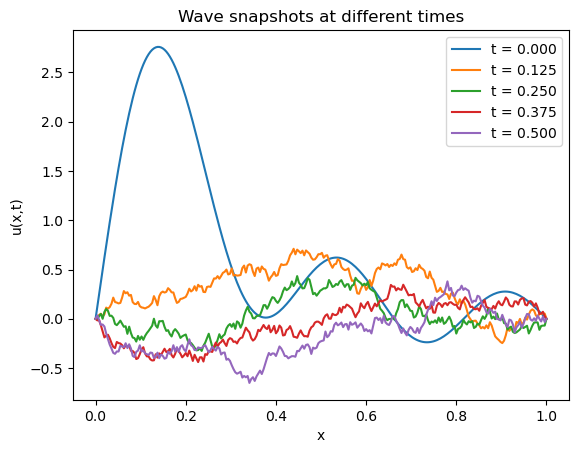

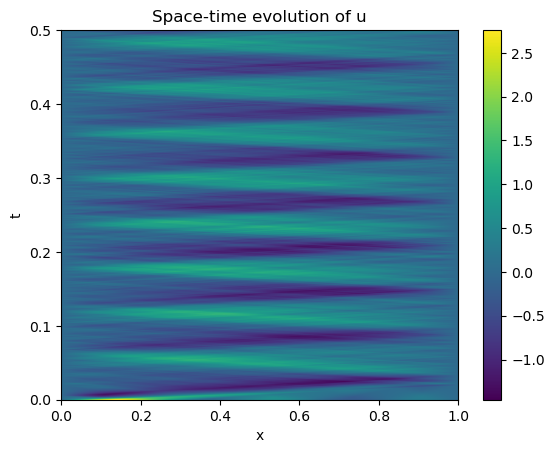

In [ ]:
# Parameters
L = 1.0
Nx = 256
dx = L / (Nx - 1)

T = 0.5   # shorter time for plotting
dt = 1e-5
Nt = int(T / dt)

x = np.linspace(0, L, Nx)

def E(eps):
    return 1.0 + 5.0 * eps**2

K = 5
np.random.seed(0)
A = np.random.uniform(0.3, 1.0, K)
B = np.random.uniform(-0.5, 0.5, K)

def u0(x):
    return sum(A[k-1] * np.sin((k)*np.pi*x/L) for k in range(1, K+1))

def v0(x):
    return sum(B[k-1] * np.sin((k)*np.pi*x/L) for k in range(1, K+1))

u = np.zeros((Nt, Nx))
u[0] = u0(x)

def compute_sigma_x(u):
    eps = (u[1:] - u[:-1]) / dx
    sigma = E(eps) * eps
    sigma_x = np.zeros_like(u)
    sigma_x[1:-1] = (sigma[1:] - sigma[:-1]) / dx
    return sigma_x

v_init = v0(x)
sigma_x_0 = compute_sigma_x(u[0])

u[1,1:-1] = u[0,1:-1] + dt*v_init[1:-1] + 0.5*dt**2*sigma_x_0[1:-1]

for n in range(1, Nt-1):
    sigma_x = compute_sigma_x(u[n])
    u[n+1,1:-1] = 2*u[n,1:-1] - u[n-1,1:-1] + dt**2*sigma_x[1:-1]

# snapshots
plt.figure()
for idx in [0, Nt//4, Nt//2, 3*Nt//4, Nt-1]:
    plt.plot(x, u[idx], label=f"t = {idx*dt:.3f}")
plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Wave snapshots at different times")
plt.legend()
plt.show()

# space-time contour
plt.figure()
plt.imshow(u, aspect='auto', origin='lower',
           extent=[0, L, 0, T])
plt.xlabel("x")
plt.ylabel("t")
plt.title("Space-time evolution of u")
plt.colorbar()
plt.show()

In [121]:
X, T_grid = np.meshgrid(x, np.linspace(0, T, Nt))

x_data = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
t_data = torch.tensor(T_grid.flatten(), dtype=torch.float32).unsqueeze(1)
u_data = torch.tensor(u.flatten(), dtype=torch.float32).unsqueeze(1)

### PINN Implementation

In [ ]:
# ------------------------
# u(x,t) network
# ------------------------
class UNet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))


# ------------------------
# E(epsilon) network
# ------------------------
class ENet(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(1, 32), nn.Tanh(),
            nn.Linear(32, 32), nn.Tanh(),
            nn.Linear(32, 1)
        )

    def forward(self, eps):
        # enforce positivity
        return torch.nn.functional.softplus(self.net(eps))

In [114]:
def gradients(u, x):
    return torch.autograd.grad(
        u, x,
        grad_outputs=torch.ones_like(u),
        create_graph=True
    )[0]

In [176]:
def pde_residual(model_u, model_E, x, t):
    x.requires_grad_(True)
    t.requires_grad_(True)

    u = model_u(x, t)

    u_x = gradients(u, x)
    u_t = gradients(u, t)
    u_tt = gradients(u_t, t)

    eps = u_x
    E = model_E(eps)

    flux = E * u_x
    flux_x = gradients(flux, x)

    return u_tt - flux_x

In [149]:
def ic_loss(model_u, x_ic, u_ic_true, v_ic_true):
    t0 = torch.zeros_like(x_ic)

    u_pred = model_u(x_ic, t0)

    t0.requires_grad_(True)
    u = model_u(x_ic, t0)
    u_t = gradients(u, t0)

    return torch.mean((u_pred - u_ic_true)**2) + torch.mean((u_t - v_ic_true)**2)

def bc_loss(model_u, t_bc):
    x_left = torch.zeros_like(t_bc)
    x_right = torch.ones_like(t_bc) * L

    u_left = model_u(x_left, t_bc)
    u_right = model_u(x_right, t_bc)

    return torch.mean(u_left**2) + torch.mean(u_right**2)

def loss_fn(model_u, model_E,
            x_data, t_data, u_data,
            x_phys, t_phys,
            x_ic, t_bc):

    # Data loss
    u_pred = model_u(x_data, t_data)
    loss_data = torch.mean((u_pred - u_data)**2)

    # Physics loss
    res = pde_residual(model_u, model_E, x_phys, t_phys)
    loss_phys = torch.mean(res**2)

    # IC loss
    loss_ic = ic_loss(model_u, x_ic, u_ic_true, v_ic_true)

    # BC loss
    loss_bc = bc_loss(model_u, t_bc)

    # Total
    total_loss = (
        loss_data
        + 10 * loss_phys
        + loss_ic
        + loss_bc
    )

    return total_loss, loss_data, loss_phys, loss_ic, loss_bc

In [130]:
# number of collocation points
N_phys = 2000

x_phys = torch.rand(N_phys, 1) * L
t_phys = torch.rand(N_phys, 1) * T

x_phys.requires_grad_(True)
t_phys.requires_grad_(True)

# IC points (x, t=0)
N_ic = 200
x_ic = torch.rand(N_ic, 1) * L

# BC points (t, x=0 or L)
N_bc = 200
t_bc = torch.rand(N_bc, 1) * T

x_ic_np = x_ic.detach().numpy()

u_ic_true = torch.tensor(u0(x_ic_np), dtype=torch.float32)
v_ic_true = torch.tensor(v0(x_ic_np), dtype=torch.float32)

In [177]:
model_u = UNet()
model_E = ENet()

optimizer = torch.optim.Adam(
    list(model_u.parameters()) + list(model_E.parameters()),
    lr=1e-3
)

for epoch in range(10000):
    optimizer.zero_grad()

    total, l_data, l_phys, l_ic, l_bc = loss_fn(
        model_u, model_E,
        x_data, t_data, u_data,
        x_phys, t_phys,
        x_ic, t_bc
    )

    total.backward()
    optimizer.step()

    if epoch % 500 == 0:
        print(f"""
            Epoch {epoch} | Total   : {total.item():.4e} 
            Data    : {l_data.item():.4e} | Physics : {l_phys.item():.4e} | IC      : {l_ic.item():.4e} | BC      : {l_bc.item():.4e}
            """)


            Epoch 0 | Total   : 1.7162e+00 
            Data    : 2.8442e-01 | Physics : 1.9559e-04 | IC      : 1.3741e+00 | BC      : 5.5721e-02
            

            Epoch 500 | Total   : 1.0048e+00 
            Data    : 3.3640e-01 | Physics : 2.0743e-03 | IC      : 6.2090e-01 | BC      : 2.6801e-02
            

            Epoch 1000 | Total   : 8.2312e-01 
            Data    : 3.8958e-01 | Physics : 4.2594e-04 | IC      : 4.2019e-01 | BC      : 9.0939e-03
            

            Epoch 1500 | Total   : 8.0250e-01 
            Data    : 4.0421e-01 | Physics : 1.8543e-04 | IC      : 3.8971e-01 | BC      : 6.7270e-03
            

            Epoch 2000 | Total   : 7.8841e-01 
            Data    : 4.0500e-01 | Physics : 1.8453e-04 | IC      : 3.7668e-01 | BC      : 4.8847e-03
            

            Epoch 2500 | Total   : 7.7135e-01 
            Data    : 4.1689e-01 | Physics : 1.9240e-04 | IC      : 3.4785e-01 | BC      : 4.6800e-03
            

            Epoch 3000 | 

### Validation and Comparison

In [178]:
def compute_mse(model_u, x, t, u_true):
    with torch.no_grad():
        u_pred = model_u(x, t)
        return torch.mean((u_pred - u_true)**2).item()

def relative_l2(model_u, x, t, u_true):
    with torch.no_grad():
        u_pred = model_u(x, t)
        return (torch.norm(u_pred - u_true) / torch.norm(u_true)).item()

print(f"Relative L2 Error: {relative_l2(model_u, x_batch, t_batch, u_batch):.4e}")
print(f"MSE: {compute_mse(model_u, x_batch, t_batch, u_batch):.4e}")

Relative L2 Error: 1.3368e+00
MSE: 4.7606e-01


In [179]:
eps_test = torch.linspace(-1, 1, 200).unsqueeze(1)

with torch.no_grad():
    E_pred = model_E(eps_test).numpy()

E_true = 1 + 5 * eps_test.numpy()**2

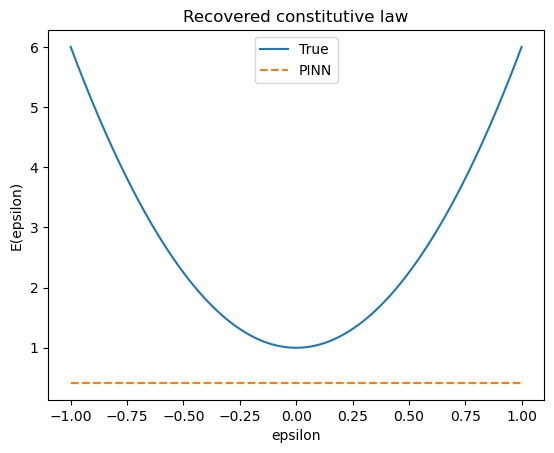

In [180]:
plt.figure()
plt.plot(eps_test.numpy(), E_true, label="True")
plt.plot(eps_test.numpy(), E_pred, '--', label="PINN")
plt.xlabel("epsilon")
plt.ylabel("E(epsilon)")
plt.legend()
plt.title("Recovered constitutive law")
plt.show()

In [181]:
E_error = np.linalg.norm(E_pred - E_true) / np.linalg.norm(E_true)
print("Relative error in E:", E_error)

Relative error in E: 0.8845912


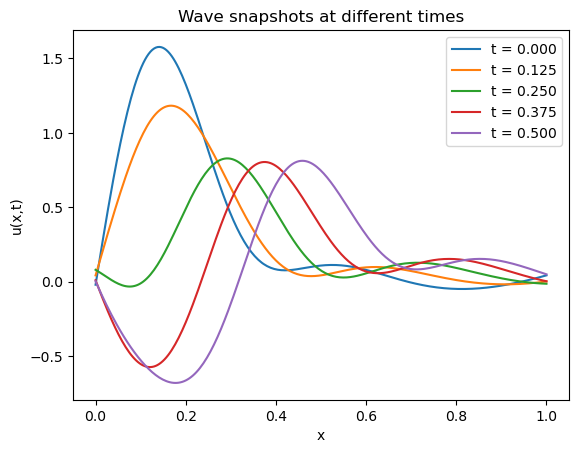

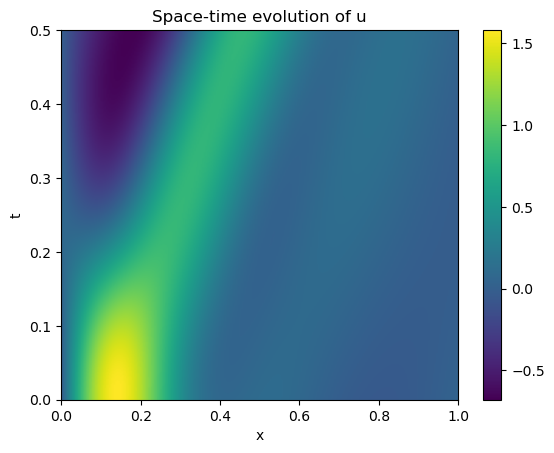

In [182]:
X, T_grid = np.meshgrid(x, np.linspace(0, T, Nt))

x_full = torch.tensor(X.flatten(), dtype=torch.float32).unsqueeze(1)
t_full = torch.tensor(T_grid.flatten(), dtype=torch.float32).unsqueeze(1)

with torch.no_grad():
    u_pred_full = model_u(x_full, t_full).cpu().numpy()

u_pred_full = u_pred_full.reshape(Nt, Nx)

# snapshots
plt.figure()
for idx in [0, Nt//4, Nt//2, 3*Nt//4, Nt-1]:
    plt.plot(x, u_pred_full[idx], label=f"t = {idx*dt:.3f}")

plt.xlabel("x")
plt.ylabel("u(x,t)")
plt.title("Wave snapshots at different times")
plt.legend()
plt.show()

# space-time contour
plt.figure()
plt.imshow(u_pred_full, aspect='auto', origin='lower',
           extent=[0, L, 0, T])
plt.xlabel("x")
plt.ylabel("t")
plt.title("Space-time evolution of u")
plt.colorbar()
plt.show()

### Architecture

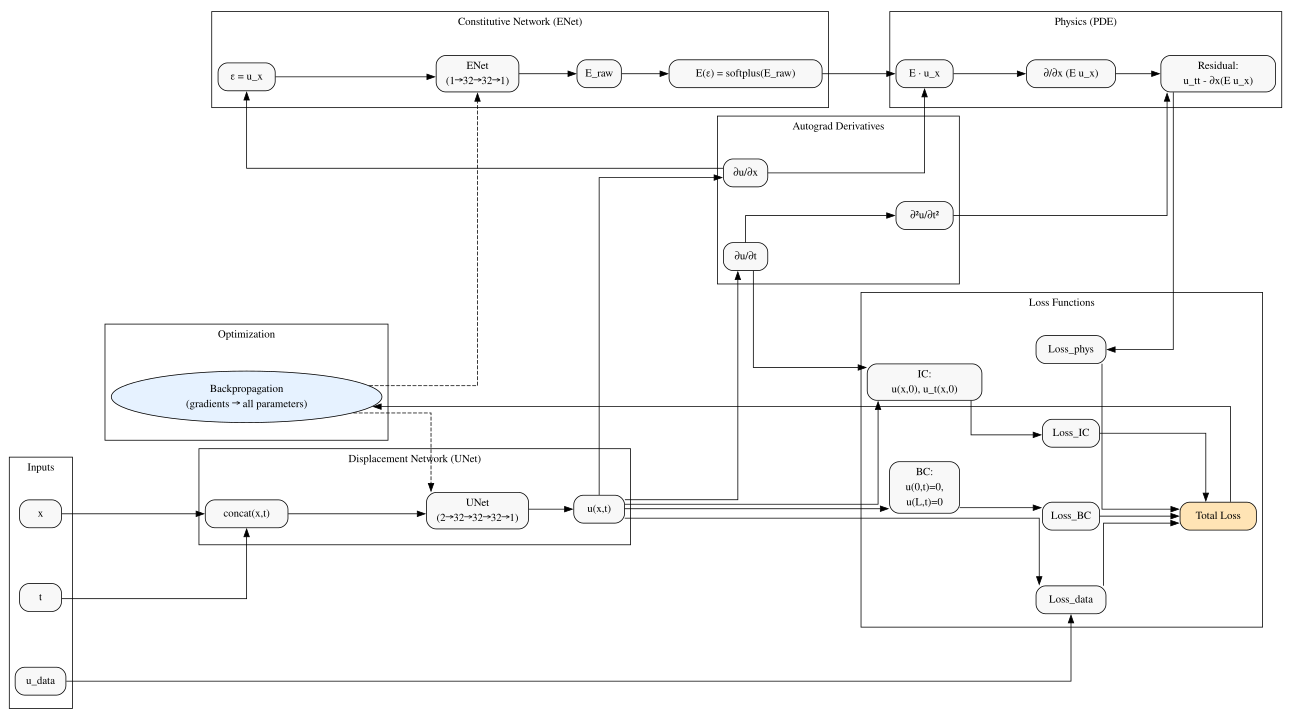

In [195]:
from graphviz import Source

dotcode = r"""
digraph PINN {
    rankdir=LR;
    splines=ortho;
    nodesep=0.6;
    ranksep=0.8;

    node [shape=box, style="rounded,filled", fillcolor="#f8f8f8"];
    graph [size="18,10!", ratio=fill];

    # -----------------------
    # Inputs
    # -----------------------
    subgraph cluster_inputs {
        label="Inputs";
        x [label="x"];
        t [label="t"];
        u_data [label="u_data"];
    }

    # -----------------------
    # UNet
    # -----------------------
    subgraph cluster_unet {
        label="Displacement Network (UNet)";
        concat [label="concat(x,t)"];
        u_net [label="UNet\n(2→32→32→32→1)"];
        u [label="u(x,t)"];

        x -> concat;
        t -> concat;
        concat -> u_net -> u;
    }

    # -----------------------
    # Derivatives (Autograd)
    # -----------------------
    subgraph cluster_derivatives {
        label="Autograd Derivatives";

        u_x [label="∂u/∂x"];
        u_t [label="∂u/∂t"];
        u_tt [label="∂²u/∂t²"];

        u -> u_x;
        u -> u_t;
        u_t -> u_tt;
    }

    # -----------------------
    # ENet (Constitutive law)
    # -----------------------
    subgraph cluster_enet {
        label="Constitutive Network (ENet)";

        eps [label="ε = u_x"];
        E_net [label="ENet\n(1→32→32→1)"];
        E_raw [label="E_raw"];
        E [label="E(ε) = softplus(E_raw)"];

        # explicit dependency
        u_x -> eps;

        eps -> E_net -> E_raw -> E;
    }

    # -----------------------
    # PDE
    # -----------------------
    subgraph cluster_pde {
        label="Physics (PDE)";

        flux [label="E · u_x"];
        flux_x [label="∂/∂x (E u_x)"];
        residual [label="Residual:\nu_tt - ∂x(E u_x)"];

        E -> flux;
        u_x -> flux;
        flux -> flux_x;

        u_tt -> residual;
        flux_x -> residual;
    }

    # -----------------------
    # Losses
    # -----------------------
    subgraph cluster_losses {
        label="Loss Functions";

        loss_data [label="Loss_data"];
        loss_ic [label="Loss_IC"];
        loss_bc [label="Loss_BC"];
        loss_phys [label="Loss_phys"];
        total_loss [label="Total Loss", fillcolor="#ffe4b5"];

        # Data
        u -> loss_data;
        u_data -> loss_data;

        # IC
        ic_block [label="IC:\nu(x,0), u_t(x,0)"];
        u -> ic_block;
        u_t -> ic_block;
        ic_block -> loss_ic;

        # BC
        bc_block [label="BC:\nu(0,t)=0,\nu(L,t)=0"];
        u -> bc_block;
        bc_block -> loss_bc;

        # Physics
        residual -> loss_phys;

        # Total
        loss_data -> total_loss;
        loss_ic -> total_loss;
        loss_bc -> total_loss;
        loss_phys -> total_loss;
    }

    # -----------------------
    # Backprop
    # -----------------------
    subgraph cluster_backprop {
        label="Optimization";

        backprop [label="Backpropagation\n(gradients → all parameters)", shape=ellipse, fillcolor="#e6f2ff"];
    }

    total_loss -> backprop;

    # Gradient flow (dashed)
    backprop -> u_net [style=dashed];
    backprop -> E_net [style=dashed];
}"""

Source(dotcode)

## Question 2

The advection-diffusion equation is given by,

$$
\frac{\partial u}{\partial t} + \alpha \frac{\partial u}{\partial x} - \epsilon \frac{\partial^2 u}{\partial x^2} = 0, \quad x \in \Omega, \quad t > 0
$$

with initial and boundary conditions,

$$
u(x, 0) = f(x), \quad x \in \Omega
$$

$$
u(x, t) = g(x, t), \quad x \in \partial\Omega, \quad t > 0
$$


In the advection dominated regime, where, $\epsilon = 0$ and $\alpha = 0.1, 1, 10$, investigate gradient pathology, by computing the eigenvalues of the kernel corresponding to the boundary conditions and the PDE residual. How can spectral bias be mitigated in this case?

In the diffusion dominated regime, where, $\epsilon = 10$ and $\alpha = 0.1$, investigate gradient pathology, by computing the eigenvalues of the kernel corresponding to the boundary conditions and the PDE residual. Is spectral bias observed in this case? If not, why?

For the general case of $\epsilon = 1$ and $\alpha = 1$, investigate gradient pathology and spectral bias.

In [253]:
import torch
import torch.nn as nn
import numpy as np
import matplotlib.pyplot as plt
import copy

device = "cuda" if torch.cuda.is_available() else "cpu"

In [261]:
class PINN(nn.Module):
    def __init__(self):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(2, 64), nn.Tanh(),
            nn.Linear(64, 64), nn.Tanh(),
            nn.Linear(64, 1)
        )

    def forward(self, x, t):
        return self.net(torch.cat([x, t], dim=1))

def initial_condition(x):
    return torch.sin(10 * np.pi * x)

def sample_ic(N_i=100):
    x_i = torch.rand(N_i, 1, device=device)
    t_i = torch.zeros(N_i, 1, device=device)
    return x_i, t_i

def sample_points(N_r=200, N_b=100):
    x_r = torch.rand(N_r, 1, device=device)
    t_r = torch.rand(N_r, 1, device=device)

    x_b = torch.zeros(N_b, 1, device=device)
    t_b = torch.rand(N_b, 1, device=device)

    return x_r, t_r, x_b, t_b

def residual(model, x, t, alpha, epsilon):
    x = x.clone().detach().requires_grad_(True)
    t = t.clone().detach().requires_grad_(True)

    u = model(x, t)

    u_t = torch.autograd.grad(u, t, torch.ones_like(u), create_graph=True)[0]
    u_x = torch.autograd.grad(u, x, torch.ones_like(u), create_graph=True)[0]
    u_xx = torch.autograd.grad(u_x, x, torch.ones_like(u_x), create_graph=True)[0]

    return u_t + alpha * u_x - epsilon * u_xx

def loss_fn(model, x_r, t_r, x_b, t_b, x_i, t_i, alpha, epsilon):
    r = residual(model, x_r, t_r, alpha, epsilon)
    loss_r = torch.mean(r**2)

    u_b = model(x_b, t_b)
    loss_b = torch.mean(u_b**2)

    u_i = model(x_i, t_i)
    u_true = torch.sin(10 * np.pi * x_i)
    loss_i = torch.mean((u_i - u_true)**2)

    total = loss_r + loss_b + loss_i

    return total, loss_r.item(), loss_b.item(), loss_i.item()

def train(model, alpha, epsilon, epochs=5000, lr=1e-3):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)

    history = []
    cond_history = []
    snapshots = {}
    model_snapshots = {}

    for epoch in range(epochs):
        x_r, t_r, x_b, t_b = sample_points()
        x_i, t_i = sample_ic()

        optimizer.zero_grad()
        loss, loss_r, loss_b, loss_i = loss_fn(model, x_r, t_r, x_b, t_b, x_i, t_i, alpha, epsilon)
        loss.backward()
        optimizer.step()

        history.append(loss.item())

        # NTK snapshots
        if epoch in [1000, 2000, 3000, 4000, 4999]:
            print(f"\n--- NTK at epoch {epoch} ---")
            K = compute_ntk_from_model(model, alpha, epsilon)
            cond = torch.linalg.cond(K).item()
            cond_history.append((epoch, cond))
            snapshots[epoch] = K
            model_snapshots[epoch] = copy.deepcopy(model)
            print(f"Condition number: {cond:.2e}")

        if epoch % 200 == 0:
            print(f"Epoch {epoch}: Loss={loss.item():.4e}")

    return history, snapshots, cond_history, model_snapshots

def compute_jacobian(y, model):
    params = [p for p in model.parameters() if p.requires_grad]
    J = []

    for i in range(y.shape[0]):
        grads = torch.autograd.grad(
            y[i], params,
            retain_graph=True,
            create_graph=False,
            allow_unused=True
        )

        grads = [
            g.flatten() if g is not None else torch.zeros_like(p).flatten()
            for g, p in zip(grads, params)
        ]

        J.append(torch.cat(grads))

    return torch.stack(J)

def compute_ntk(J):
    return J @ J.T

def compute_ntk_from_model(model, alpha, epsilon):
    x_r, t_r, x_b, t_b = sample_points(N_r=100, N_b=50)
    x_i, t_i = sample_ic(N_i=50)

    # Residual
    r = residual(model, x_r, t_r, alpha, epsilon)

    # Boundary
    u_b = model(x_b, t_b)

    # Initial condition
    u_i = model(x_i, t_i)
    u_true = torch.sin(10 * np.pi * x_i)

    # Stack ALL outputs (this is key)
    y = torch.cat([
        r,
        u_b,
        (u_i - u_true)
    ], dim=0)

    J = compute_jacobian(y, model)
    K = compute_ntk(J)

    K += 1e-6 * torch.eye(K.shape[0], device=device)

    return K

def plot_multiple_spectra(snapshots, alpha, epsilon):
    plt.figure()

    for epoch, K in snapshots.items():
        eigvals = torch.linalg.eigvals(K).real.cpu().detach().numpy()
        eigvals = np.sort(eigvals)[::-1]

        plt.semilogy(eigvals, label=f"Epoch {epoch}")

    plt.xlabel("Index")
    plt.ylabel("Eigenvalue (log scale)")
    plt.title(f"NTK Spectrum Evolution (α={alpha}, ε={epsilon})")
    plt.legend()
    plt.grid()
    plt.show()

def plot_loss(history, alpha, epsilon):
    plt.figure()
    plt.semilogy(history)
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Training Loss (α={alpha}, ε={epsilon})")
    plt.grid()
    plt.show()

def plot_condition(cond_history, alpha, epsilon):
    epochs = [e for e, _ in cond_history]
    conds = [c for _, c in cond_history]

    plt.figure()
    plt.semilogy(epochs, conds, 'o-')
    plt.xlabel("Epoch")
    plt.ylabel("Condition Number")
    plt.title(f"NTK Conditioning Over Training (α={alpha}, ε={epsilon})")
    plt.grid()
    plt.show()

def fourier_spectrum(u, x):
    u_np = u.detach().cpu().numpy().flatten()
    fft = np.fft.fft(u_np)
    return np.abs(fft)


def plot_fourier_evolution(model_snapshots, alpha, epsilon):
    plt.figure()

    x = torch.linspace(0, 1, 256).unsqueeze(1).to(device)
    t = torch.ones_like(x) * 0.5

    for epoch, model in model_snapshots.items():
        u = model(x, t)
        spectrum = np.abs(np.fft.fft(u.detach().cpu().numpy().flatten()))

        plt.semilogy(spectrum[:50], label=f"Epoch {epoch}")

    plt.xlabel("Mode")
    plt.ylabel("Amplitude (log)")
    plt.title(f"Fourier Spectrum Evolution (α={alpha}, ε={epsilon})")
    plt.legend()
    plt.grid()
    plt.show()

def plot_solution(model, title):
    x = torch.linspace(0, 1, 200).unsqueeze(1).to(device)

    plt.figure()

    for t_val in [0.0, 0.25, 0.5, 0.75]:
        t = torch.ones_like(x) * t_val
        u = model(x, t).detach().cpu().numpy()
        plt.plot(x.cpu(), u, label=f"t={t_val}")

    plt.title(title)
    plt.legend()
    plt.grid()
    plt.show()

def plot_error_spectrum(model_snapshots, alpha, epsilon):
    plt.figure()

    x = torch.linspace(0,1,256).unsqueeze(1).to(device)
    t = torch.ones_like(x) * 0.5

    x_np = x.cpu().numpy().flatten()

    for epoch, model in model_snapshots.items():
        u_pred = model(x,t).detach().cpu().numpy().flatten()

        u_true = np.sin(10*np.pi*(x_np - alpha*0.5)) \
                 * np.exp(-epsilon*(10*np.pi)**2 * 0.5)

        error = u_pred - u_true
        fft_err = np.abs(np.fft.fft(error))

        plt.semilogy(fft_err[:50], label=f"Epoch {epoch}")

    plt.xlabel("Mode")
    plt.ylabel("Error (log)")
    plt.title(f"Error Spectrum Evolution (α={alpha}, ε={epsilon})")
    plt.legend()
    plt.grid()
    plt.show()

def run_full(alpha, epsilon):
    print(f"\n=== Running (α={alpha}, ε={epsilon}) ===")

    model = PINN().to(device)

    # -------------------------
    # Training
    # -------------------------
    history, snapshots, cond_history, model_snapshots = train(model, alpha, epsilon)

    # -------------------------
    # NTK + Loss diagnostics
    # -------------------------
    plot_loss(history, alpha, epsilon)
    plot_multiple_spectra(snapshots, alpha, epsilon)
    plot_condition(cond_history, alpha, epsilon)

    # -------------------------
    # Qualitative plots
    # -------------------------

    plot_solution(model, f"Solution Evolution (α={alpha}, ε={epsilon})")
    plot_fourier_evolution(model_snapshots, alpha, epsilon)
    plot_error_spectrum(model_snapshots, alpha, epsilon)

### Advection Dominated Regime


=== Running (α=0.1, ε=0) ===
Epoch 0: Loss=6.2126e-01
Epoch 200: Loss=5.2151e-01
Epoch 400: Loss=5.5583e-01
Epoch 600: Loss=4.4426e-01
Epoch 800: Loss=5.5241e-01

--- NTK at epoch 1000 ---
Condition number: 1.37e+11
Epoch 1000: Loss=4.8785e-01
Epoch 1200: Loss=4.9958e-01
Epoch 1400: Loss=4.9905e-01
Epoch 1600: Loss=4.5505e-01
Epoch 1800: Loss=4.8103e-01

--- NTK at epoch 2000 ---
Condition number: 3.36e+10
Epoch 2000: Loss=5.4347e-01
Epoch 2200: Loss=5.3923e-01
Epoch 2400: Loss=4.7662e-01
Epoch 2600: Loss=5.1449e-01
Epoch 2800: Loss=4.6345e-01

--- NTK at epoch 3000 ---
Condition number: 2.37e+10
Epoch 3000: Loss=4.9647e-01
Epoch 3200: Loss=4.7039e-01
Epoch 3400: Loss=4.4368e-01
Epoch 3600: Loss=4.8388e-01
Epoch 3800: Loss=4.7752e-01

--- NTK at epoch 4000 ---
Condition number: 3.32e+10
Epoch 4000: Loss=4.5486e-01
Epoch 4200: Loss=4.7519e-01
Epoch 4400: Loss=4.7610e-01
Epoch 4600: Loss=4.9550e-01
Epoch 4800: Loss=3.9266e-01

--- NTK at epoch 4999 ---
Condition number: 2.24e+11


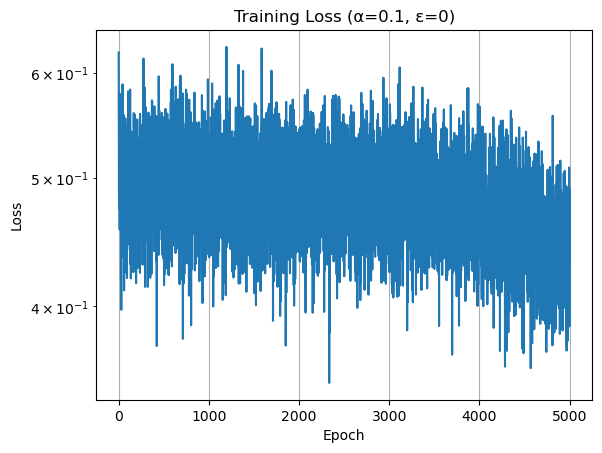

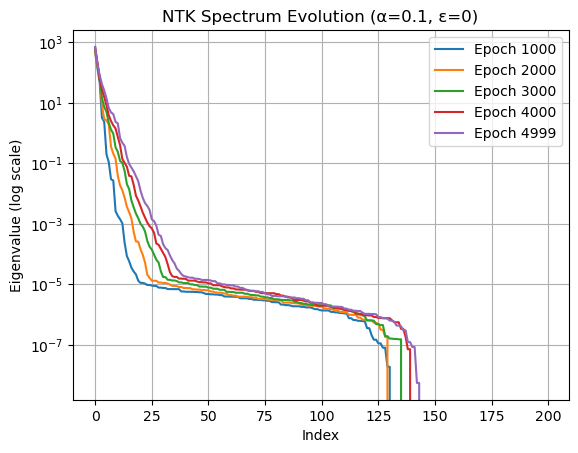

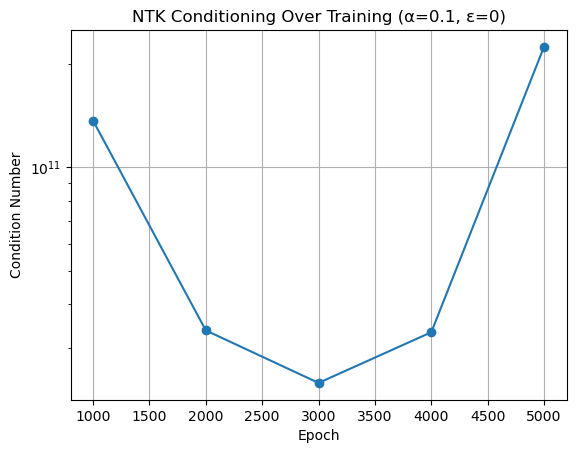

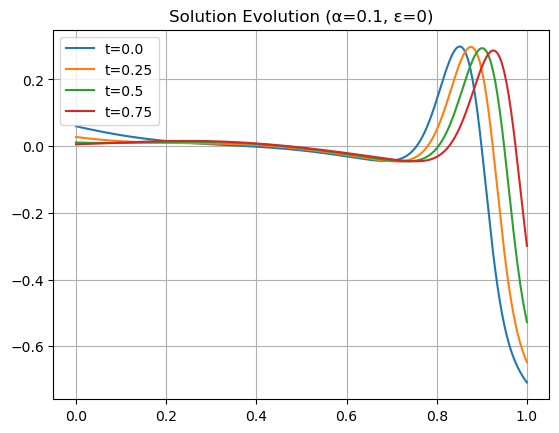

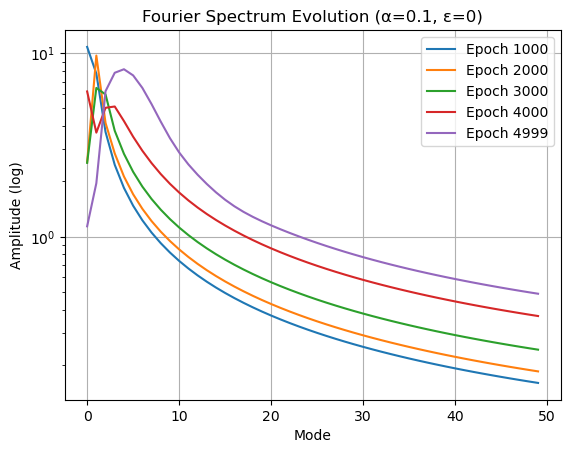

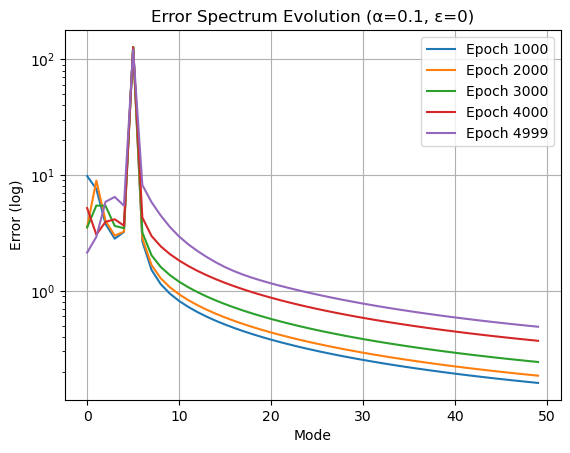


=== Running (α=1, ε=0) ===
Epoch 0: Loss=5.2529e-01
Epoch 200: Loss=5.3048e-01
Epoch 400: Loss=4.4562e-01
Epoch 600: Loss=5.3767e-01
Epoch 800: Loss=4.1073e-01

--- NTK at epoch 1000 ---
Condition number: 1.48e+11
Epoch 1000: Loss=5.1155e-01
Epoch 1200: Loss=5.0886e-01
Epoch 1400: Loss=4.1649e-01
Epoch 1600: Loss=4.7327e-01
Epoch 1800: Loss=5.1952e-01

--- NTK at epoch 2000 ---
Condition number: 4.94e+10
Epoch 2000: Loss=5.0782e-01
Epoch 2200: Loss=5.5757e-01
Epoch 2400: Loss=5.1814e-01
Epoch 2600: Loss=4.8022e-01
Epoch 2800: Loss=4.9138e-01

--- NTK at epoch 3000 ---
Condition number: 2.50e+10
Epoch 3000: Loss=4.9978e-01
Epoch 3200: Loss=4.7616e-01
Epoch 3400: Loss=4.5107e-01
Epoch 3600: Loss=5.2411e-01
Epoch 3800: Loss=5.1567e-01

--- NTK at epoch 4000 ---
Condition number: 6.34e+10
Epoch 4000: Loss=5.5394e-01
Epoch 4200: Loss=4.5572e-01
Epoch 4400: Loss=4.9065e-01
Epoch 4600: Loss=4.0320e-01
Epoch 4800: Loss=5.2591e-01

--- NTK at epoch 4999 ---
Condition number: 3.64e+12


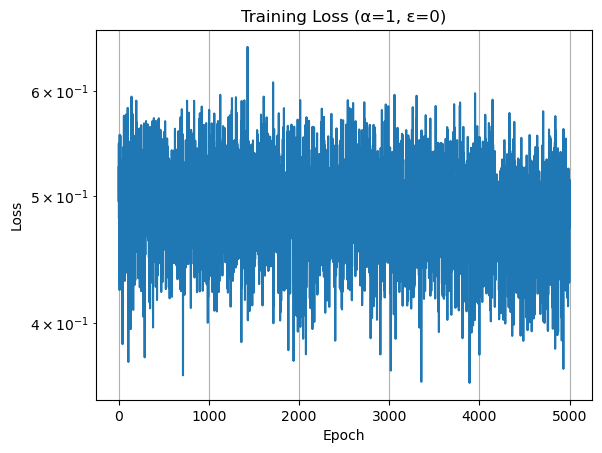

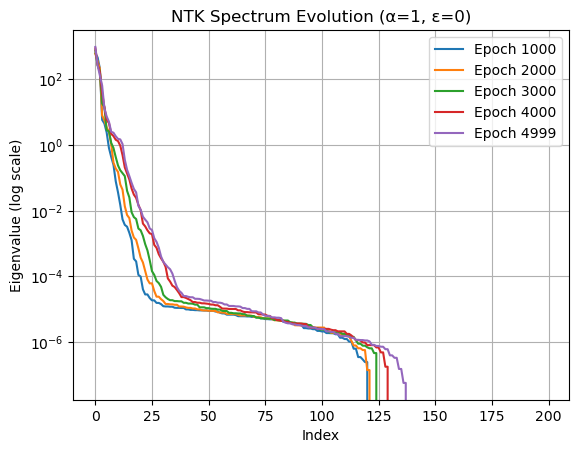

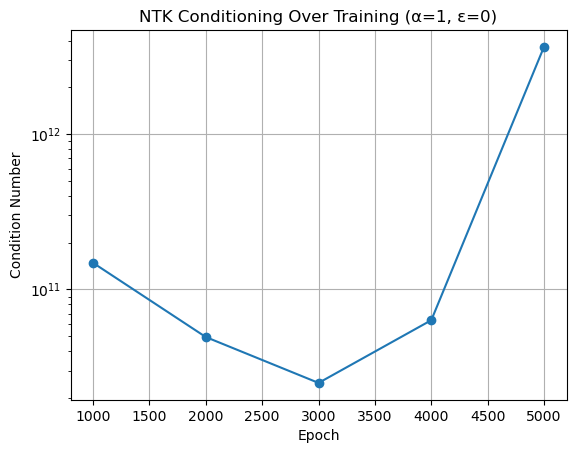

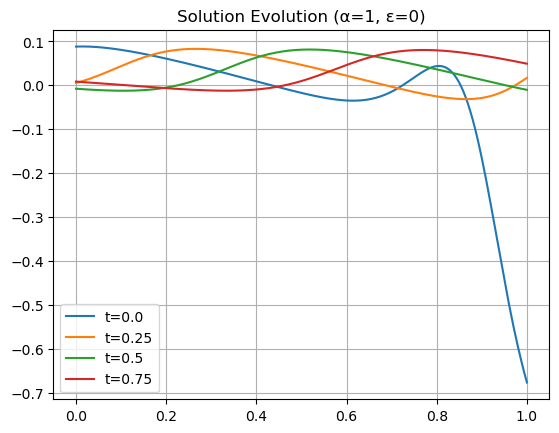

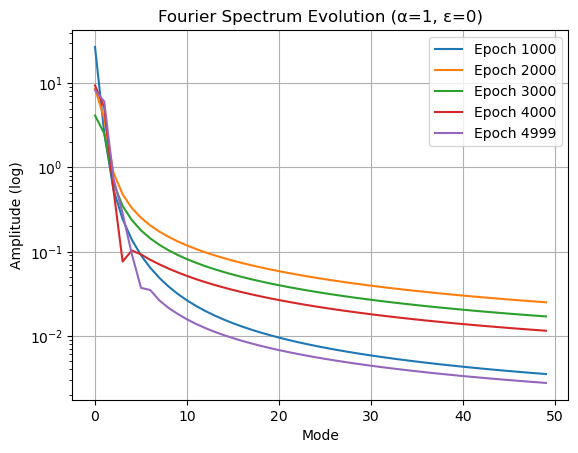

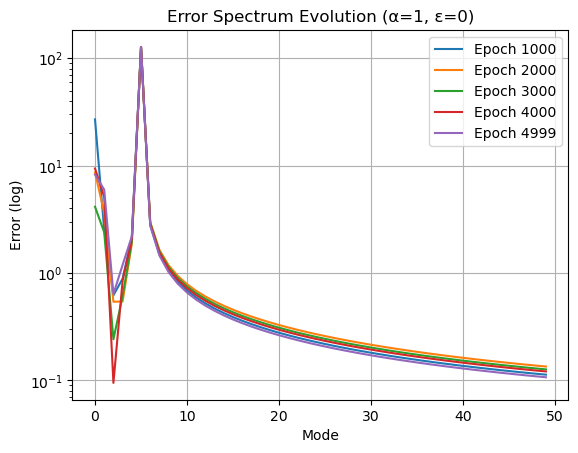


=== Running (α=10, ε=0) ===
Epoch 0: Loss=1.2983e+00
Epoch 200: Loss=5.3587e-01
Epoch 400: Loss=4.7306e-01
Epoch 600: Loss=5.3453e-01
Epoch 800: Loss=5.1268e-01

--- NTK at epoch 1000 ---
Condition number: 2.76e+12
Epoch 1000: Loss=5.2438e-01
Epoch 1200: Loss=5.2077e-01
Epoch 1400: Loss=4.3684e-01
Epoch 1600: Loss=4.6578e-01
Epoch 1800: Loss=4.6244e-01

--- NTK at epoch 2000 ---
Condition number: 6.42e+11
Epoch 2000: Loss=4.9637e-01
Epoch 2200: Loss=5.1234e-01
Epoch 2400: Loss=5.0122e-01
Epoch 2600: Loss=4.7569e-01
Epoch 2800: Loss=4.9666e-01

--- NTK at epoch 3000 ---
Condition number: 6.41e+11
Epoch 3000: Loss=4.5931e-01
Epoch 3200: Loss=4.9791e-01
Epoch 3400: Loss=4.6640e-01
Epoch 3600: Loss=4.2393e-01
Epoch 3800: Loss=5.0185e-01

--- NTK at epoch 4000 ---
Condition number: 3.73e+11
Epoch 4000: Loss=4.3270e-01
Epoch 4200: Loss=5.1400e-01
Epoch 4400: Loss=4.9864e-01
Epoch 4600: Loss=5.3012e-01
Epoch 4800: Loss=5.0937e-01

--- NTK at epoch 4999 ---
Condition number: 1.94e+12


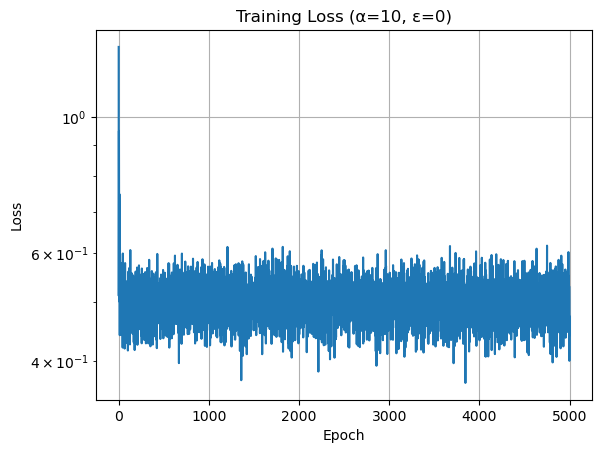

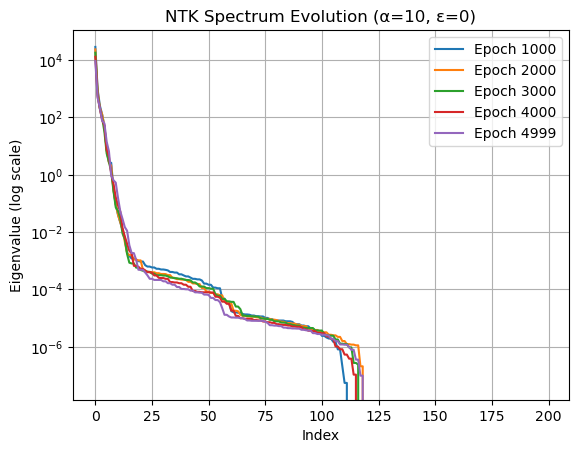

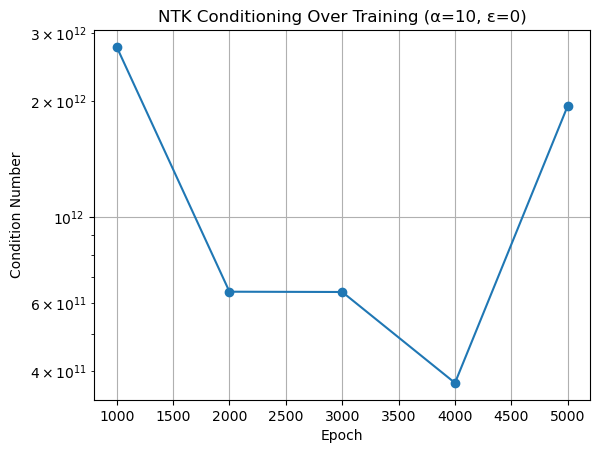

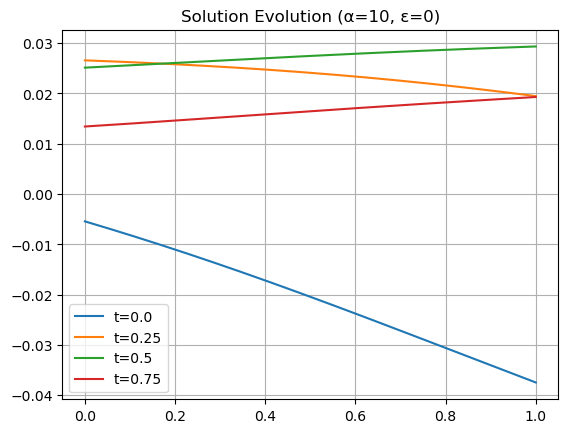

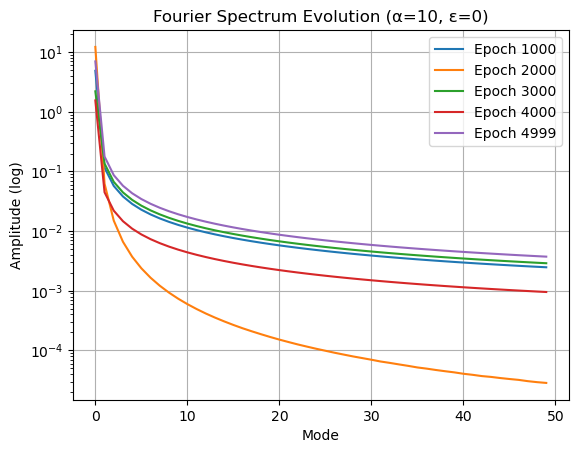

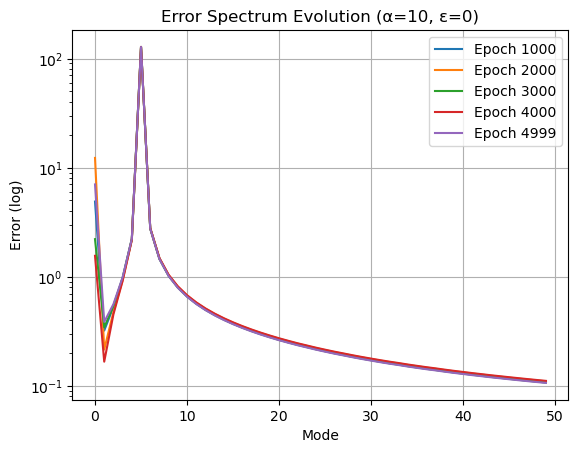

In [263]:
for alpha in [0.1, 1, 10]:
    run_full(alpha, 0)

### Diffusion Dominated Regime


=== Running (α=0.1, ε=10) ===
Epoch 0: Loss=6.7089e-01
Epoch 200: Loss=4.4247e-01
Epoch 400: Loss=4.3796e-01
Epoch 600: Loss=5.1514e-01
Epoch 800: Loss=4.8869e-01

--- NTK at epoch 1000 ---
Condition number: 1.27e+11
Epoch 1000: Loss=5.1287e-01
Epoch 1200: Loss=5.2824e-01
Epoch 1400: Loss=5.0773e-01
Epoch 1600: Loss=4.8351e-01
Epoch 1800: Loss=4.2642e-01

--- NTK at epoch 2000 ---
Condition number: 9.42e+10
Epoch 2000: Loss=4.6284e-01
Epoch 2200: Loss=4.5458e-01
Epoch 2400: Loss=4.7137e-01
Epoch 2600: Loss=5.1200e-01
Epoch 2800: Loss=5.3590e-01

--- NTK at epoch 3000 ---
Condition number: 8.93e+10
Epoch 3000: Loss=4.8808e-01
Epoch 3200: Loss=5.4647e-01
Epoch 3400: Loss=4.0425e-01
Epoch 3600: Loss=5.0982e-01
Epoch 3800: Loss=4.3779e-01

--- NTK at epoch 4000 ---
Condition number: 2.12e+10
Epoch 4000: Loss=5.5755e-01
Epoch 4200: Loss=4.5997e-01
Epoch 4400: Loss=4.8933e-01
Epoch 4600: Loss=5.3507e-01
Epoch 4800: Loss=4.7456e-01

--- NTK at epoch 4999 ---
Condition number: 4.69e+10


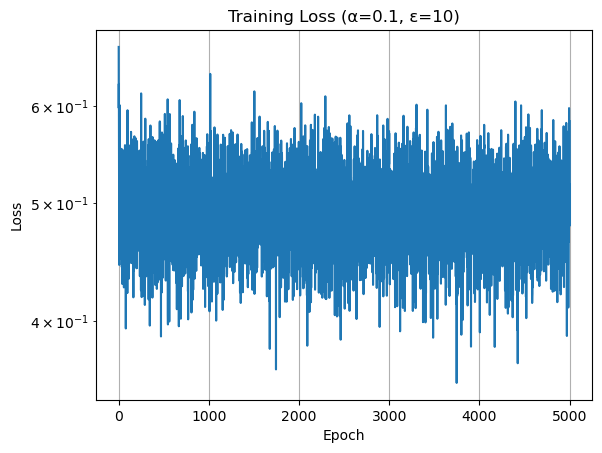

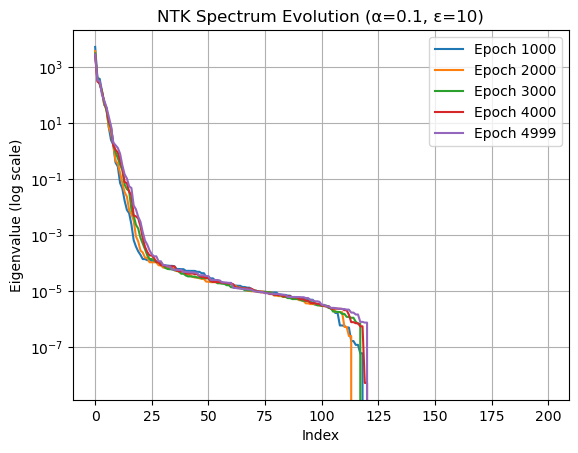

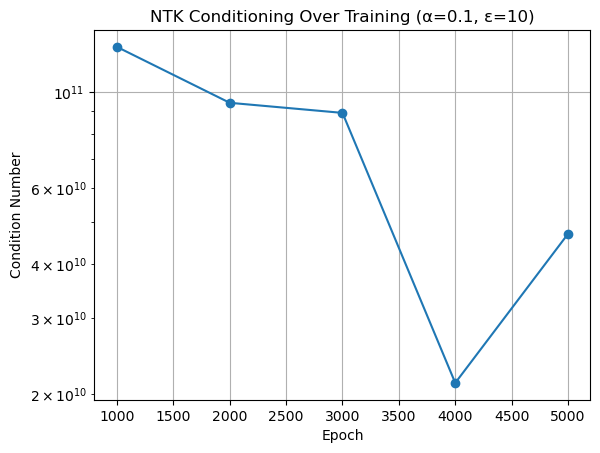

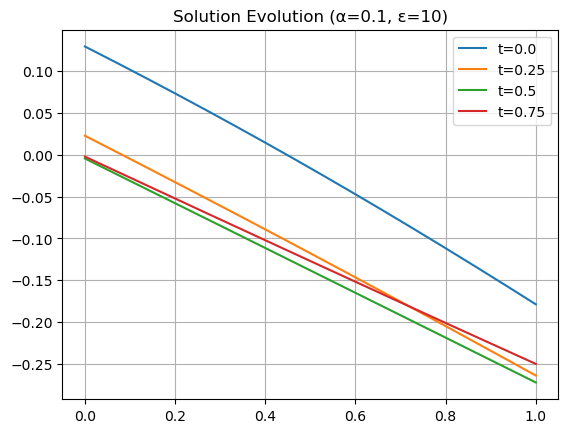

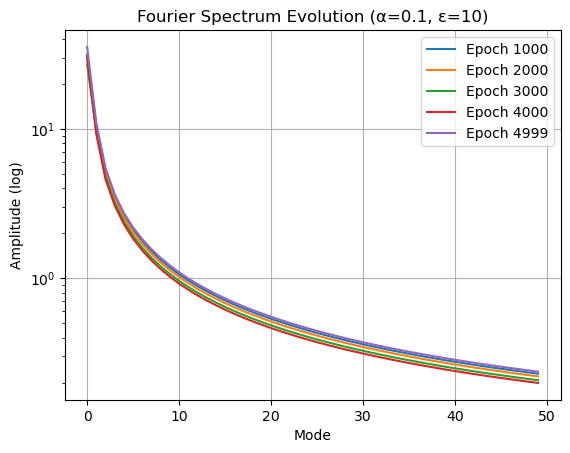

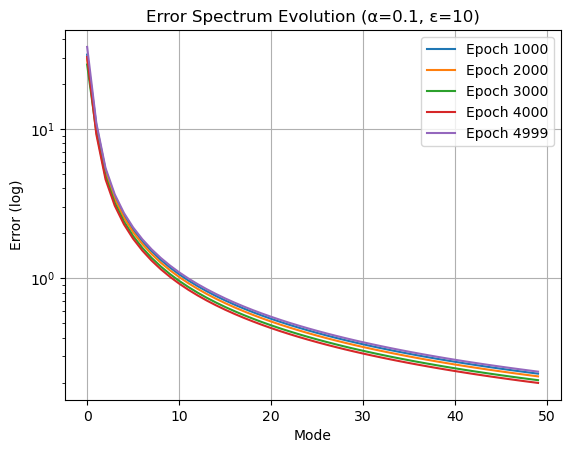

In [262]:
run_full(0.1, 10)

### General Regime


=== Running (α=1, ε=1) ===
Epoch 0: Loss=8.0671e-01
Epoch 200: Loss=5.4013e-01
Epoch 400: Loss=4.4927e-01
Epoch 600: Loss=4.8364e-01
Epoch 800: Loss=4.3009e-01

--- NTK at epoch 1000 ---
Condition number: 3.02e+10
Epoch 1000: Loss=4.6523e-01
Epoch 1200: Loss=5.0306e-01
Epoch 1400: Loss=5.1360e-01
Epoch 1600: Loss=4.9189e-01
Epoch 1800: Loss=5.1926e-01

--- NTK at epoch 2000 ---
Condition number: 3.61e+10
Epoch 2000: Loss=5.1113e-01
Epoch 2200: Loss=4.8390e-01
Epoch 2400: Loss=5.0896e-01
Epoch 2600: Loss=5.0363e-01
Epoch 2800: Loss=4.9051e-01

--- NTK at epoch 3000 ---
Condition number: 2.70e+10
Epoch 3000: Loss=4.7142e-01
Epoch 3200: Loss=4.9278e-01
Epoch 3400: Loss=5.1758e-01
Epoch 3600: Loss=5.0344e-01
Epoch 3800: Loss=5.1166e-01

--- NTK at epoch 4000 ---
Condition number: 1.55e+10
Epoch 4000: Loss=5.4985e-01
Epoch 4200: Loss=5.1591e-01
Epoch 4400: Loss=5.0269e-01
Epoch 4600: Loss=4.6728e-01
Epoch 4800: Loss=5.2134e-01

--- NTK at epoch 4999 ---
Condition number: 4.34e+10


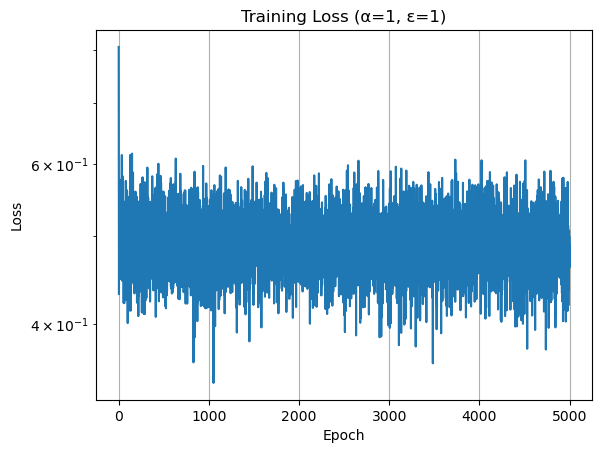

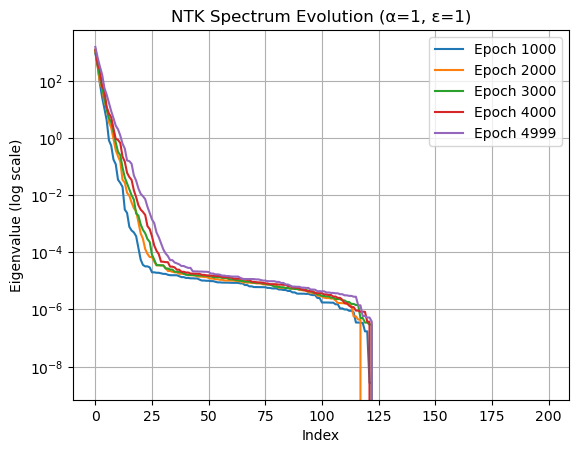

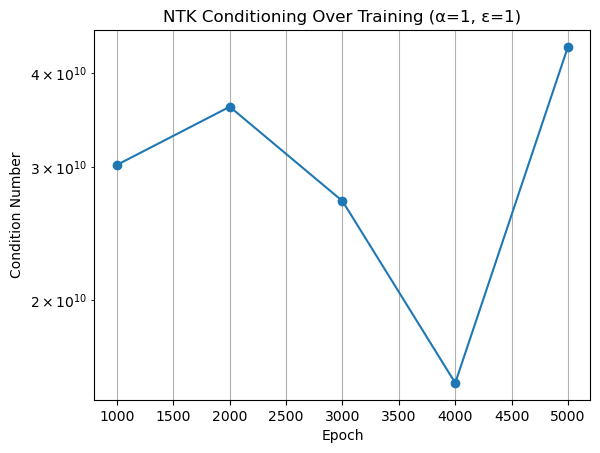

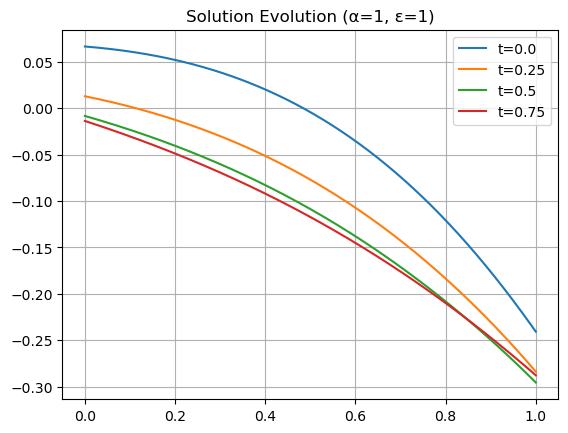

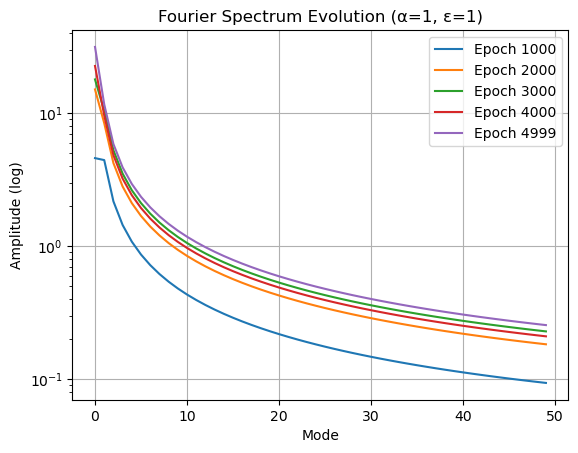

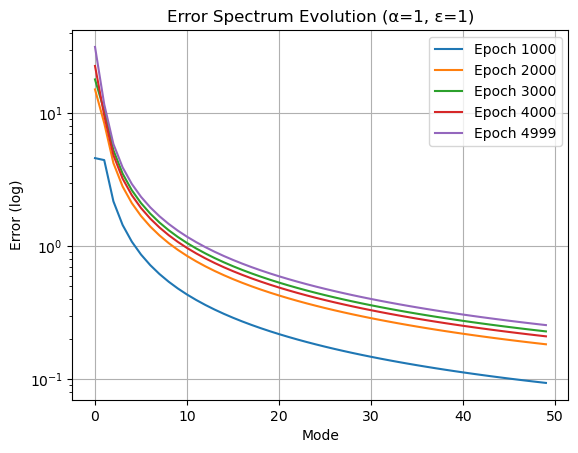

In [264]:
run_full(1, 1)